## **Credit Risk Default Prediction Engine**

Machine learning pipeline to predict borrower loan default risk using the LendingClub dataset.

Dataset: LendingClub Loan Data (2007–2018)

Goal: Predict probability of borrower default using financial and credit-history features.


Key steps:
- Data filtering and target creation
- Missing value analysis
- Data leakage detection
- Feature engineering

**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting, you can explore your Google Drive files. The root of your Drive will be at `/content/drive/My Drive/`. You can use the following code to list the contents of your Drive to find the specific file you want to load.

In [ ]:
import os

drive_path = '/content/drive/My Drive/CreditRiskEngine_DSproject/accepted_2007_to_2018Q4.csv'




In [ ]:
data=pd.read_csv(drive_path,nrows=250000)
data.head(10)

/tmp/ipykernel_198/2598490269.py:1: DtypeWarning: Columns (19,59,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(drive_path,nrows=250000)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

pd.set_option('display.max_rows', None)


In [ ]:
data.dtypes

,0
id,int64
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object


In [ ]:
data.dtypes.value_counts()

,count
float64,114
object,36
int64,1


In [ ]:
data.shape

(250000, 151)

In [ ]:
data.describe(include="all")

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
count,2.500000e+05,0.0,250000.00000,250000.00000,250000.000000,250000,250000.000000,250000.000000,250000,250000,...,1732.000000,1732.000000,250000,250000,7162,7162,7162,7162.000000,7162.000000,7162.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,7,35,...,NaN,NaN,1,2,37,3,39,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,36 months,NaN,NaN,B,C1,...,NaN,NaN,Cash,N,Oct-2018,COMPLETE,Oct-2017,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,168495,NaN,NaN,72796,15873,...,NaN,NaN,250000,242838,552,3451,402,NaN,NaN,NaN
mean,6.067526e+07,NaN,15231.41850,15231.41850,15223.208076,NaN,12.443483,440.678059,NaN,NaN,...,9752.270468,184.789099,NaN,NaN,NaN,NaN,NaN,4970.790173,47.141553,13.278693
std,4.872668e+06,NaN,8631.30629,8631.30629,8626.720611,NaN,4.275147,246.531560,NaN,NaN,...,6225.246222,179.674476,NaN,NaN,NaN,NaN,NaN,3536.034676,5.823169,7.570197
min,5.670500e+04,NaN,1000.00000,1000.00000,900.000000,NaN,5.320000,14.770000,NaN,NaN,...,55.730000,0.020000,NaN,NaN,NaN,NaN,NaN,130.000000,20.000000,0.000000
25%,5.687415e+07,NaN,8400.00000,8400.00000,8400.000000,NaN,9.170000,261.880000,NaN,NaN,...,4581.630000,44.890000,NaN,NaN,NaN,NaN,NaN,2189.387500,45.000000,8.000000
50%,6.092263e+07,NaN,14000.00000,14000.00000,14000.000000,NaN,12.290000,382.550000,NaN,NaN,...,8705.715000,134.295000,NaN,NaN,NaN,NaN,NaN,4300.000000,45.000000,12.000000
75%,6.504746e+07,NaN,20000.00000,20000.00000,20000.000000,NaN,14.850000,579.857500,NaN,NaN,...,13989.097500,273.765000,NaN,NaN,NaN,NaN,NaN,6898.720000,50.000000,18.000000


In [ ]:
data = data.loc[
    (data['loan_status'] == 'Fully Paid') |
    (data['loan_status'] == 'Charged Off')
].copy()

In [ ]:
data["default"]=(data["loan_status"]=="Charged Off").astype(int)
data[["loan_status","default"]].head(10)

,loan_status,default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0
6,Fully Paid,0
7,Fully Paid,0
8,Fully Paid,0
9,Fully Paid,0
12,Fully Paid,0


In [ ]:
data=data.drop("loan_status",axis=1)
data.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
12,68338832,NaN,1400.0,1400.0,1400.0,36 months,12.88,47.10,C,C2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
data.columns
data=data.drop("url",axis=1)

In [ ]:
data_nullcount=data.isnull().sum().sort_values(ascending=False)
data_nullcount

,0
member_id,220898
sec_app_num_rev_accts,220898
sec_app_open_act_il,220898
sec_app_revol_util,220898
sec_app_open_acc,220898
next_pymnt_d,220898
sec_app_mths_since_last_major_derog,220898
sec_app_collections_12_mths_ex_med,220898
sec_app_inq_last_6mths,220898
revol_bal_joint,220898


In [ ]:
data_nullprcnt=(data_nullcount[data_nullcount!=0]/2208.98).sort_values(ascending=False)
data_nullprcnt

,0
member_id,100.000000
sec_app_num_rev_accts,100.000000
sec_app_open_act_il,100.000000
sec_app_revol_util,100.000000
sec_app_open_acc,100.000000
next_pymnt_d,100.000000
sec_app_mths_since_last_major_derog,100.000000
sec_app_collections_12_mths_ex_med,100.000000
sec_app_inq_last_6mths,100.000000
revol_bal_joint,100.000000


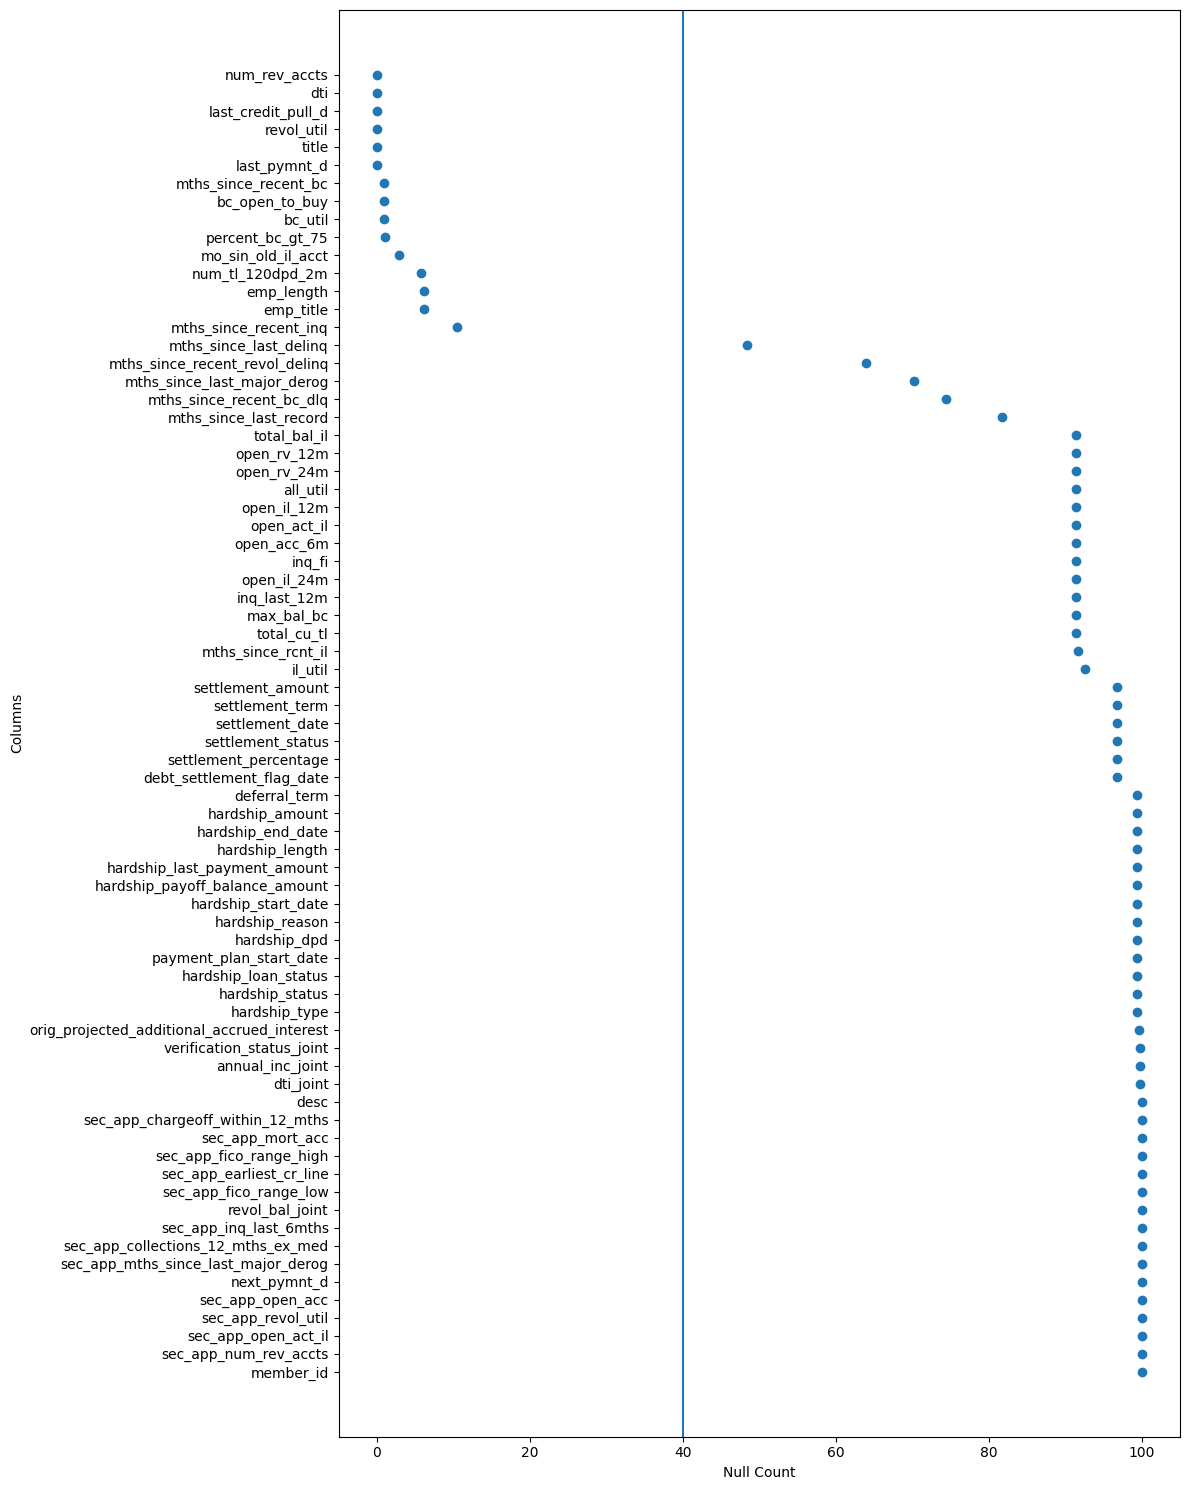

In [ ]:
plt.figure(figsize=(12,15))
plt.scatter(data_nullprcnt,data_nullprcnt.index)
plt.axvline(x=40)

plt.xlabel("Null Count")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

In [ ]:
null_40_cols=data_nullprcnt[data_nullprcnt>40]
null_40_cols

,0
member_id,100.000000
sec_app_num_rev_accts,100.000000
sec_app_open_act_il,100.000000
sec_app_revol_util,100.000000
sec_app_open_acc,100.000000
next_pymnt_d,100.000000
sec_app_mths_since_last_major_derog,100.000000
sec_app_collections_12_mths_ex_med,100.000000
sec_app_inq_last_6mths,100.000000
revol_bal_joint,100.000000


In [ ]:
null_100cols=null_40_cols[null_40_cols==100].index
data=data.drop(labels=null_100cols,axis=1)
data.head(10)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
6,68476668,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,Vice President of Recruiting Operations,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
7,67275481,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,road driver,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
8,68466926,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,SERVICE MANAGER,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
9,68616873,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,Vendor liaison,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
12,68338832,1400.0,1400.0,1400.0,36 months,12.88,47.10,C,C2,Logistics Manager,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


To check for leakage variables see if tht **column** would be known at the time of taking loan
bold text

In [ ]:
data.shape

(220898, 135)

In [ ]:
data["verification_status_joint"][~data.verification_status_joint.isna()].value_counts()

,count
verification_status_joint,
Not Verified,401


In [ ]:
print(null_40_cols[null_40_cols!=100].index)

Index(['desc', 'dti_joint', 'annual_inc_joint', 'verification_status_joint',
       'orig_projected_additional_accrued_interest', 'hardship_type',
       'hardship_status', 'hardship_loan_status', 'payment_plan_start_date',
       'hardship_dpd', 'hardship_reason', 'hardship_start_date',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'hardship_length', 'hardship_end_date', 'hardship_amount',
       'deferral_term', 'debt_settlement_flag_date', 'settlement_percentage',
       'settlement_status', 'settlement_date', 'settlement_term',
       'settlement_amount', 'il_util', 'mths_since_rcnt_il', 'total_cu_tl',
       'max_bal_bc', 'inq_last_12m', 'open_il_24m', 'inq_fi', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'all_util', 'open_rv_24m', 'open_rv_12m',
       'total_bal_il', 'mths_since_last_record', 'mths_since_recent_bc_dlq',
       'mths_since_last_major_derog', 'mths_since_recent_revol_delinq',
       'mths_since_last_delinq'],
      dtype='

In [ ]:
leakage_cols = [
    "hardship_status",
    "hardship_type",
    "hardship_start_date",
    "hardship_loan_status",
    "hardship_dpd",
    "hardship_reason",
    "hardship_end_date",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",
    "hardship_length",
    "hardship_amount",
    "payment_plan_start_date",
    "deferral_term",
    "orig_projected_additional_accrued_interest",

    "settlement_percentage",
    "settlement_amount",
    "settlement_status",
    "settlement_date",
    "settlement_term",
    "debt_settlement_flag_date"
]


In [ ]:
cols = null_40_cols[null_40_cols!=100].index
bin_matrix = data[cols].notna().astype(int)
bin_matrix["default"] = data["default"]

In [ ]:
corr_matrix = bin_matrix.corr()
corr_matrix["default"].sort_values(ascending=False)

,default
default,1.000000
settlement_percentage,0.363429
debt_settlement_flag_date,0.363429
settlement_date,0.363429
settlement_term,0.363429
settlement_status,0.363429
settlement_amount,0.363429
hardship_reason,0.079865
payment_plan_start_date,0.079865
hardship_loan_status,0.079865


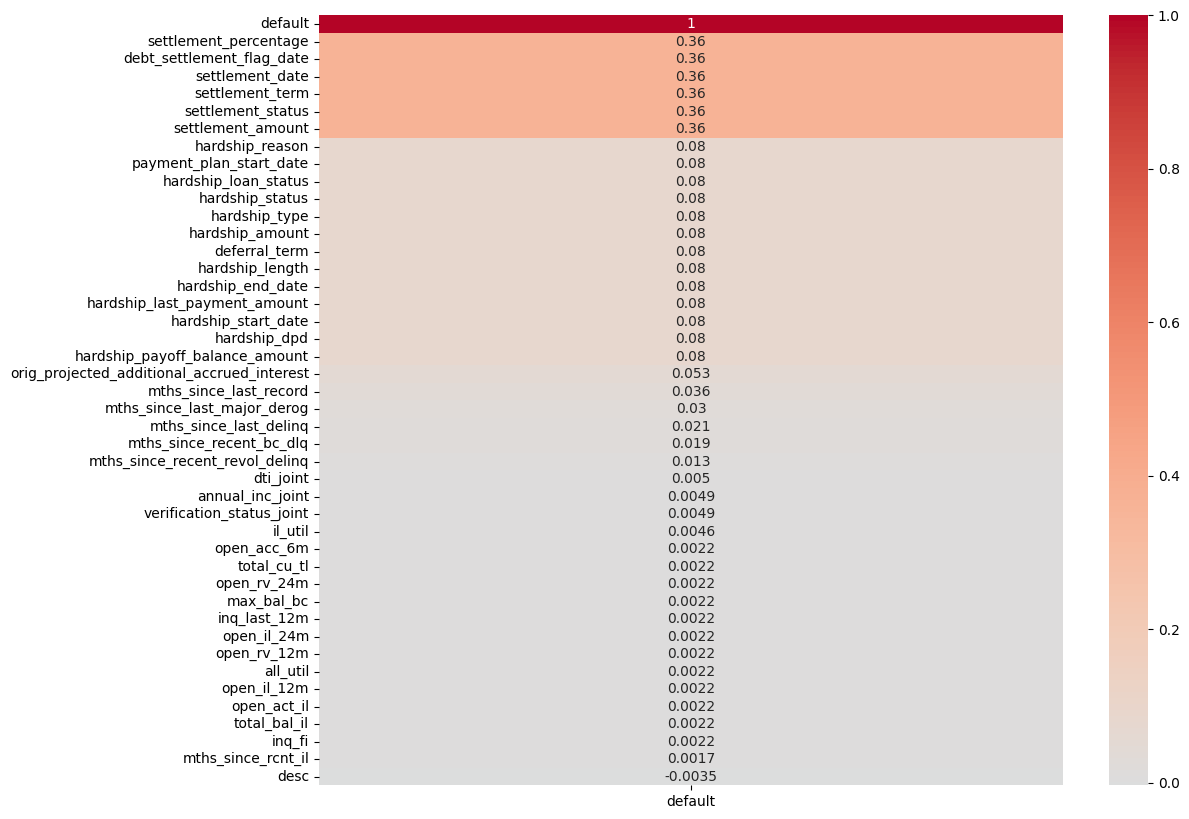

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix[["default"]].sort_values(by="default", ascending=False),
            annot=True, cmap="coolwarm", center=0)
plt.show()

In [ ]:
data=data.drop(leakage_cols,axis=1)
data.shape

(220898, 115)

In [ ]:
((data.isnull().sum()/data.shape[0])*100).sort_values(ascending=False)


,0
mths_since_last_record,81.703320
mths_since_recent_bc_dlq,74.364186
mths_since_last_major_derog,70.223814
mths_since_recent_revol_delinq,63.968891
mths_since_recent_inq,10.512092
emp_title,6.154877
emp_length,6.145823
num_tl_120dpd_2m,5.816259
mo_sin_old_il_acct,2.963359
percent_bc_gt_75,1.029434


In [ ]:
data["delinq_missing"] = data["mths_since_last_delinq"].isna().astype(int)
data["mths_since_last_delinq"] = data["mths_since_last_delinq"].fillna(999)

In [ ]:
data["default"].value_counts()/data.shape[0]

,count
default,
0,0.79955
1,0.20045


In [ ]:
irr_sparse = [
"desc",
"dti_joint",
"annual_inc_joint",
"verification_status_joint",
"il_util",
"mths_since_rcnt_il",
"all_util",
"max_bal_bc",
"open_rv_24m",
"open_rv_12m",
"open_il_12m",
"total_bal_il",
"open_il_24m",
"open_act_il",
"open_acc_6m",
"inq_fi",
"inq_last_12m",
"total_cu_tl"
]
data=data.drop(irr_sparse,axis=1)
data.shape

(220898, 97)

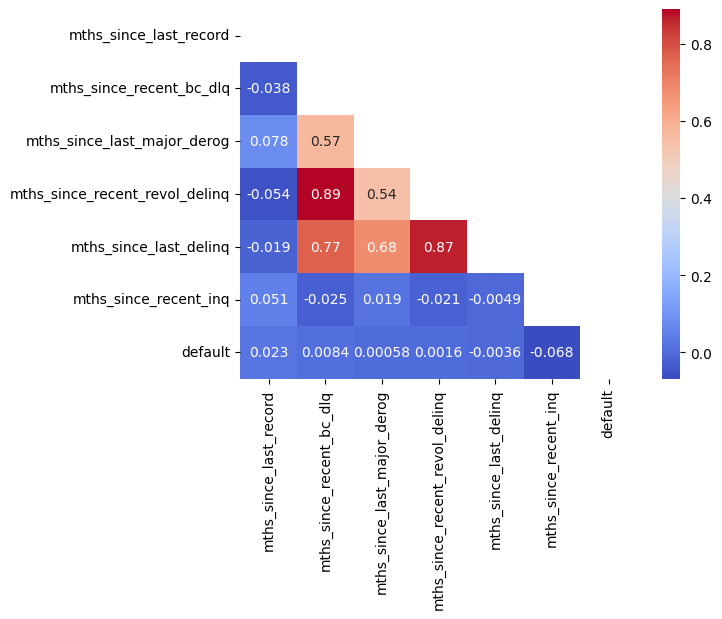

In [ ]:
cols = [
    "mths_since_last_record",
    "mths_since_recent_bc_dlq",
    "mths_since_last_major_derog",
    "mths_since_recent_revol_delinq",
    "mths_since_last_delinq",
    "mths_since_recent_inq",
    "default"
]

corr = data[cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, mask=mask,cmap="coolwarm" )

plt.show()

In [ ]:
data.shape

(220898, 85)

In [ ]:
leakage_cols=["last_pymnt_d",
"last_pymnt_amnt",
"last_credit_pull_d",
"collection_recovery_fee",
"recoveries",
"total_rec_int",
"total_rec_late_fee",
"total_rec_prncp",
"total_pymnt",
"total_pymnt_inv",
"out_prncp",
"out_prncp_inv"]
data=data.drop(leakage_cols,axis=1)

In [ ]:
data[['delinq_2yrs','mths_since_last_delinq']][(data["delinq_2yrs"]==1) &
                                               (data["mths_since_last_delinq"]==999)].head(20)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().